In [ ]:
# This notebook needs a GPU runtime.
!nvidia-smi

Fri Sep 27 16:58:28 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA L4                      Off | 00000000:00:03.0 Off |                    0 |
| N/A   36C    P8              11W /  72W |      1MiB / 23034MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

## Install dependencies.

In [ ]:
!pip install tqdm
!pip install faiss-cpu
!pip install timm
!pip install opencv-python
!pip install mediapy
!pip install open3d
!pip install git+https://github.com/lucasb-eyer/pydensecrf.git
!git clone https://github.com/normandipalo/dino-vit-features.git
import sys
sys.path.append('dino-vit-features')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.0/27.0 MB 85.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 83.1 MB/s eta 0:00:00
  Using cached jedi-0.19.1-py2.py3-none-any.whl.metadata (22 kB)
Using cached jedi-0.19.1-py2.py3-none-any.whl (1.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.7/399.7 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 88.8 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.9
    Uninstalling widgetsnbextension-3.6.9:
      Successfully uninstalled widgetsnbextension-3.6.9
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Su

In [ ]:
import keypoint_utils
import mediapy as media
import numpy as np

Downloading: "https://github.com/facebookresearch/dino/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dino/dino_deitsmall8_pretrain/dino_deitsmall8_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dino_deitsmall8_pretrain.pth
100%|██████████| 82.7M/82.7M [00:00<00:00, 270MB/s]


In [ ]:
for image_i in range(0,4):
  image_path = f"dino-vit-features/images/can_{image_i}.jpg"
  image = media.read_image(image_path)
  image = media.resize_image(image, (480,480))
  media.write_image(f"dino-vit-features/images/can_{image_i}.jpg", image)

## Computing correspondences and finding keypoints on all images.

In [ ]:
# Select the paths of a pair of images from which you want to extract keypoint correspondences.
patches_xy, desc1, descriptor_vectors, num_patches = keypoint_utils.extract_descriptors("dino-vit-features/images/can_0.jpg", "dino-vit-features/images/can_1.jpg", num_pairs = 5, load_size = 480)

Using cache found in /root/.cache/torch/hub/facebookresearch_dino_main


image1_batch.size torch.Size([1, 3, 480, 480])
num_patches1 (60, 60)
img1_indices_to_show tensor([1286, 1766, 1107, 1890, 1711], device='cuda:0')
img2_indices_to_show tensor([1298, 1776, 1119, 1961, 1782], device='cuda:0')
num patches (60, 60)


image1_batch.size torch.Size([1, 3, 480, 480])
torch.Size([60, 60, 6528])
emb_im shape torch.Size([60, 60, 6528])
cs_i.shape torch.Size([60, 60])
cs_i.shape torch.Size([60, 60])
cs_i.shape torch.Size([60, 60])
cs_i.shape torch.Size([60, 60])
cs_i.shape torch.Size([60, 60])


""

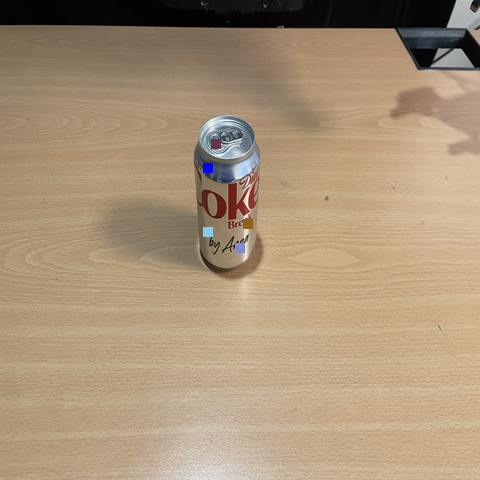

image1_batch.size torch.Size([1, 3, 480, 480])
torch.Size([60, 60, 6528])
emb_im shape torch.Size([60, 60, 6528])
cs_i.shape torch.Size([60, 60])
cs_i.shape torch.Size([60, 60])
cs_i.shape torch.Size([60, 60])
cs_i.shape torch.Size([60, 60])
cs_i.shape torch.Size([60, 60])


""

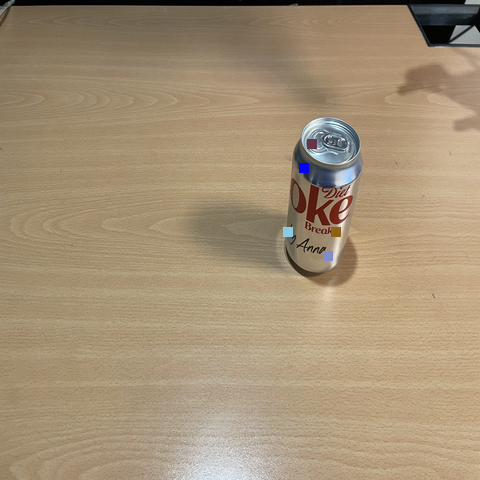

image1_batch.size torch.Size([1, 3, 480, 480])
torch.Size([60, 60, 6528])
emb_im shape torch.Size([60, 60, 6528])
cs_i.shape torch.Size([60, 60])
cs_i.shape torch.Size([60, 60])
cs_i.shape torch.Size([60, 60])
cs_i.shape torch.Size([60, 60])
cs_i.shape torch.Size([60, 60])


""

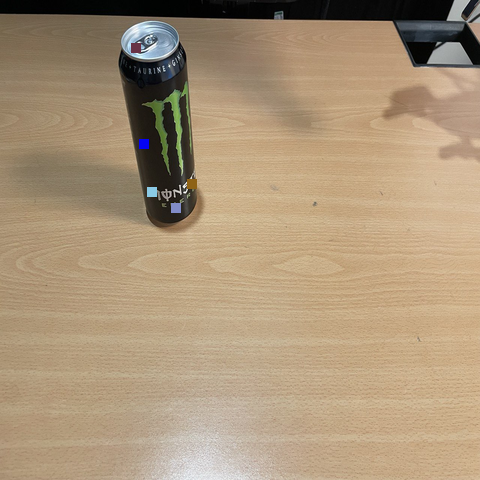

image1_batch.size torch.Size([1, 3, 480, 480])
torch.Size([60, 60, 6528])
emb_im shape torch.Size([60, 60, 6528])
cs_i.shape torch.Size([60, 60])
cs_i.shape torch.Size([60, 60])
cs_i.shape torch.Size([60, 60])
cs_i.shape torch.Size([60, 60])
cs_i.shape torch.Size([60, 60])


""

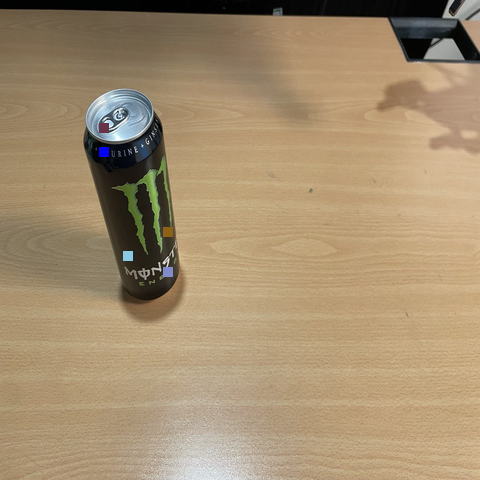

In [ ]:
# Now find the keypoints corresponding to the extracted descriptors
# in any new image. The method assumes the image are squared.
y_list, x_list = [], []

colors = np.random.randint(0,255, 3*20).reshape((-1,3))
for image_i in range(0,4):
  image_path = f"dino-vit-features/images/can_{image_i}.jpg"
  map3, _ = keypoint_utils.extract_desc_maps(image_path)
  print(map3[0].shape)
  cs_ys_list, cs_xs_list = keypoint_utils.extract_descriptor_nn(descriptor_vectors, map3[0], num_patches, False)
  y_list.append(cs_ys_list)
  x_list.append(cs_xs_list)
  input_image = media.resize_image(media.read_image(image_path), (480,480))
  output_image = keypoint_utils.draw_keypoints(input_image, cs_ys_list, cs_xs_list, colors = colors)
  media.show_image(output_image)

In [ ]:
# These keypoints can then become the inputs for Keypoint Action Tokens.
keypoints = np.concatenate([np.array(cs_ys_list).reshape((-1,1)), np.array(cs_xs_list).reshape((-1,1))], axis = -1)

In [ ]:
def record_demo():
  """
  Implement yourself based on your robot architecture.
  Outputs a recorded trajectory of the robot. It can be in many different
  forms, although we suggest either the poses of e.g. the end-effector wrist and fingertips
  or the pose of the end-effector wrist and an axis-angle representation of the orientation.
  For better results the poses should be in the same cartesian space as the keypoints.
  """
  pass

In [ ]:
# Given the observation from the environment, you can extract keypoints
# as above, and then store the demonstration trajectory based on your
# preferred action space, and use it as the output in the prompt.

TIMESTEPS = 20
DEMOS = 4
demo_trajectory = record_demo() # Not a real function!

# This is what it could look like if using Action tokens (excluding gripper),
# assuming the woorld coordinates go from 0 to 500, as the Action Tokens are 3 3D points.
demo_trajectories = np.random.randint(0,500, DEMOS*9*TIMESTEPS).reshape((DEMOS,TIMESTEPS,9))


In [ ]:
# This is how 4 demos would look like, that you can then add to
# the LLM prompt. The inputs in this example are 2D, but generally can be 3D given a depth value.
print("""You are a pattern generator machine. I will give you a
series of patterns with INPUTS and OUTPUTS as examples.
Then, you will receive a new INPUTS, and you have to generate
OUTPUTS following the pattern that appears in the data. The
points are (x,y,z) coordinates. Only reply with the OUTPUTS
numbers.""")
for i in range(len(demo_trajectories)):
  keypoints = np.concatenate([np.array(y_list[i]).reshape((-1,1)), np.array(x_list[i]).reshape((-1,1))], axis = -1)
  print("INPUTS:")
  print(keypoints)
  print("OUTPUTS:")
  print(demo_trajectories[i])

You are a pattern generator machine. I will give you a
series of patterns with INPUTS and OUTPUTS as examples.
Then, you will receive a new INPUTS, and you have to generate
OUTPUTS following the pattern that appears in the data. The
points are (x,y,z) coordinates. Only reply with the OUTPUTS
numbers.
INPUTS:
[[168 208]
 [232 208]
 [144 216]
 [248 240]
 [224 248]]
OUTPUTS:
[[163 257 436 138 255 282 108 272 124]
 [453  57  83 401 250 177 330 301 325]
 [271 194  13 124 118 257 349 217 390]
 [309  56 207 313 497 164 395 399 328]
 [309 449 210 185 402 298 447 317 116]
 [ 47  78 196  89 127 319 442  36 436]
 [237 152 375 316 127  24 270 168  15]
 [ 20 185 269 225 187 402 233  77 429]
 [189  21 201  53  93 414  24  36  89]
 [130 367 168  35 276  84 247 296  63]
 [206 466  80  35 327 192 385 164  23]
 [478 210 434  86 405 298 400 466 197]
 [ 19 295 426  56  62 328 363 313 222]
 [483 193  81 302 132 160  59  85 236]
 [269 116  41   1 309 361  80  94 382]
 [ 68  75  68 468  25 339 470 440 458]
 